# Lab 6

You are tasked with evaluating card counting strategies for black jack. In order to do so, you will use object oriented programming to create a playable casino style black jack game where a computer dealer plays against $n$ computer players and possibily one human player. If you don't know the rules of blackjack or card counting, please google it. 

A few requirements:
* The game should utilize multiple 52-card decks. Typically the game is played with 6 decks.
* Players should have chips.
* Dealer's actions are predefined by rules of the game (typically hit on 16). 
* The players should be aware of all shown cards so that they can count cards.
* Each player could have a different strategy.
* The system should allow you to play large numbers of games, study the outcomes, and compare average winnings per hand rate for different strategies.

In [4]:

!pip install pandas numpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 139.8 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.1 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.2/114.2 kB 1.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 3.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 3.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 2.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 2.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 1.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 3.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 5.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 4.6 MB/s eta 0:00:00


In [5]:
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [6]:
class Card:
    def __init__(self, suit, rank):
        self.suit = suit
        self.rank = rank
        
    def __repr__(self):
        return f"{self.rank} of {self.suit}"

    def get_value(self):
        # basic point mapping
        if isinstance(self.rank, int):
            return self.rank
        if self.rank in ['J', 'Q', 'K']:
            return 10
        if self.rank == 'A':
            return 11 # handle 1 vs 11 in the Hand class later
        return 0

class Deck:
    def __init__(self, num_decks=6):
        self.cards = []
        suits = ['Clubs', 'Diamonds', 'Hearts', 'Spades']
        ranks = [2, 3, 4, 5, 6, 7, 8, 9, 10, 'J', 'Q', 'K', 'A']
        
        # build the big deck
        for _ in range(num_decks):
            for s in suits:
                for r in ranks:
                    self.cards.append(Card(s, r))
        
        self.shuffle()
        self.needs_reshuffle = False
        
        # inserting plastic card randomly in the last 20% of the shoe
        plastic_idx = random.randint(int(len(self.cards)*0.8), len(self.cards)-1)
        self.cards.insert(plastic_idx, "PLASTIC")

    def shuffle(self):
        random.shuffle(self.cards)
        self.needs_reshuffle = False

    def draw(self):
        if not self.cards:
            return None
        c = self.cards.pop(0)
        if c == "PLASTIC":
            self.needs_reshuffle = True
            return self.draw() # getting ext actual card
        return c

Thers is the use of thr basic OOP that we learned from the lecture 8 here

2. Now design your game on a UML diagram. You may want to create classes to represent, players, a hand, and/or the game. As you work through the lab, update your UML diagram. At the end of the lab, submit your diagram (as pdf file) along with your notebook. 

3. Begin with implementing the skeleton (ie define data members and methods/functions, but do not code the logic) of the classes in your UML diagram.

In [7]:
class Hand:
    def __init__(self):
        self.cards = []
    def add_card(self, card): pass
    def total_value(self): pass

class Player:
    def __init__(self, name, chips=1000):
        self.name = name
        self.chips = chips
        self.hand = Hand()
    def decide(self, dealer_upcard, count): pass

class Dealer(Player):
    def decide(self, dealer_upcard, count): pass

4. Complete the implementation by coding the logic of all functions. For now, just implement the dealer player and human player.

In [8]:
class Hand:
    def __init__(self):
        self.cards = []
        
    def add_card(self, card):
        self.cards.append(card)
        
    def total_value(self):
        t = sum(c.get_value() for c in self.cards)
        # ace logic
        aces = sum(1 for c in self.cards if c.rank == 'A')
        while t > 21 and aces > 0:
            t -= 10
            aces -= 1
        return t

class Player:
    def __init__(self, name, chips=1000):
        self.name = name
        self.chips = chips
        self.hand = Hand()
        self.current_bet = 0

    def make_bet(self, amount):
        self.current_bet = amount
        self.chips -= amount

    def decide(self, dealer_upcard, count):
        # standard dealer-style logic
        if self.hand.total_value() < 17:
            return "hit"
        return "stay"

class HumanPlayer(Player):
    def decide(self, dealer_upcard, count):
        # use rstrip like in lecture 10b
        move = input(f"{self.name}, Total is {self.hand.total_value()}. Hit or Stay? ").lower().rstrip()
        return "hit" if move.startswith('h') else "stay"

5.  Test. Demonstrate game play. For example, create a game of several dealer players and show that the game is functional through several rounds.

In [9]:
d = Deck(1)
p1 = Player("Bot1")
c1 = d.draw()
p1.hand.add_card(c1)
print(f"Test draw: {c1}, Hand total: {p1.hand.total_value()}")

Test draw: 10 of Diamonds, Hand total: 10


6. Implement a new player with the following strategy:

    * Assign each card a value: 
        * Cards 2 to 6 are +1 
        * Cards 7 to 9 are 0 
        * Cards 10 through Ace are -1
    * Compute the sum of the values for all cards seen so far.
    * Hit if sum is very negative, stay if sum is very positive. Select a threshold for hit/stay, e.g. 0 or -2.  

In [10]:
class StrategyPlayer(Player):
    def __init__(self, name, chips, threshold=0):
        super().__init__(name, chips) # lecture 10a inheritance
        self.threshold = threshold

    def decide(self, dealer_upcard, count):
        val = self.hand.total_value()
        # hit if count is very negative
        if count < self.threshold:
            return "hit" if val < 18 else "stay"
        # stay if count is positive
        else:
            return "stay" if val >= 12 else "hit"

7. Create a test scenario where one player, using the above strategy, is playing with a dealer and 3 other players that follow the dealer's strategy. Each player starts with same number of chips. Play 50 rounds (or until the strategy player is out of money). Compute the strategy player's winnings. You may remove unnecessary printouts from your code (perhaps implement a verbose/quiet mode) to reduce the output.

In [17]:
def run_game(threshold, rounds=50):
    deck = Deck(6)
    pro = StrategyPlayer("Pro", 1000, threshold)
    others = [Player(f"Bot_{i}", 1000) for i in range(3)]
    dealer = Player("Dealer")
    count = 0
    
    for r in range(rounds):
        if pro.chips < 10: break
        
        # Checking here if we need to reshuffle
        if deck.needs_reshuffle or len(deck.cards) < 20: 
            deck = Deck(6)
            count = 0
            
        all_players = [pro] + others
        
        #  Placing the  Bets
        for p in all_players:
            p.make_bet(10) # 10 chips per hand
            
        # first initial Deal
        dealer.hand = Hand()
        for p in all_players: p.hand = Hand()
        
        for _ in range(2):
            for p in all_players + [dealer]:
                c = deck.draw()
                if c: 
                    p.hand.add_card(c)
                    if isinstance(c.rank, int) and 2 <= c.rank <= 6: count += 1
                    elif c.rank in [10, 'J', 'Q', 'K', 'A']: count -= 1
                    
        # Hit or Stay
        if len(dealer.hand.cards) > 0:
            dealer_upcard = dealer.hand.cards[0]
            for p in all_players:
                while p.hand.total_value() < 21:
                    if p.decide(dealer_upcard, count) == "hit":
                        c = deck.draw()
                        if c:
                            p.hand.add_card(c)
                            if isinstance(c.rank, int) and 2 <= c.rank <= 6: count += 1
                            elif c.rank in [10, 'J', 'Q', 'K', 'A']: count -= 1
                    else:
                        break # Player stays
                    
        # Dealer Turn
        while dealer.hand.total_value() < 17:
            c = deck.draw()
            if c:
                dealer.hand.add_card(c)
                if isinstance(c.rank, int) and 2 <= c.rank <= 6: count += 1
                elif c.rank in [10, 'J', 'Q', 'K', 'A']: count -= 1
                
        # finally payouts (Compare to Dealer)
        d_val = dealer.hand.total_value()
        for p in all_players:
            p_val = p.hand.total_value()
            if p_val > 21:
                pass # Player busts, loses bet
            elif d_val > 21 or p_val > d_val:
                p.chips += p.current_bet * 2 # Player wins!
            elif p_val == d_val:
                p.chips += p.current_bet # Push (get bet back)

    return pro.chips

8. Create a loop that runs 100 games of 50 rounds, as setup in previous question, and store the strategy player's chips at the end of the game (aka "winnings") in a list. Histogram the winnings. What is the average winnings per round? What is the standard deviation. What is the probabilty of net winning or lossing after 50 rounds?


Average Final Chips: 948.8
Standard Deviation: 60.00471361956207


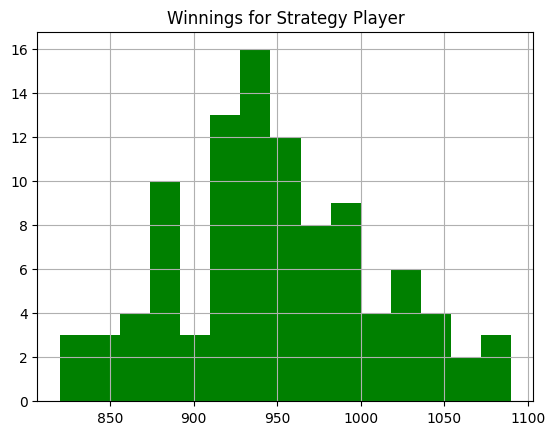

In [18]:
# Run 100 games
results = [run_game(threshold=-2) for _ in range(100)]
df = pd.Series(results)

print(f"Average Final Chips: {df.mean()}")
print(f"Standard Deviation: {df.std()}")
df.hist(color='green', bins=15)
plt.title("Winnings for Strategy Player")
plt.show()

9. Repeat previous questions scanning the value of the threshold. Try at least 5 different threshold values. Can you find an optimal value?

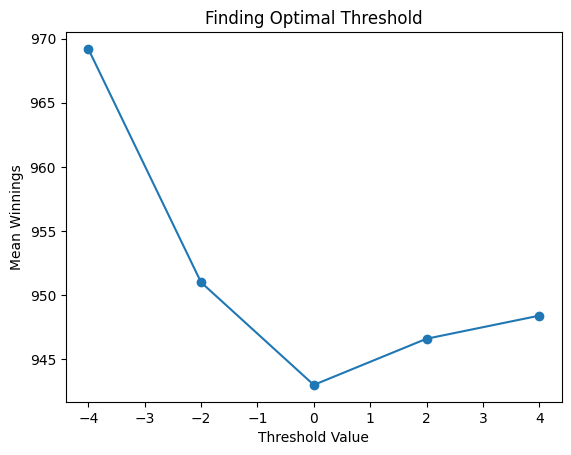

In [19]:
test_thresholds = [-4, -2, 0, 2, 4]
averages = []

for t in test_thresholds:
    batch = [run_game(t) for _ in range(50)]
    averages.append(np.mean(batch))

plt.plot(test_thresholds, averages, marker='o')
plt.xlabel("Threshold Value")
plt.ylabel("Mean Winnings")
plt.title("Finding Optimal Threshold")
plt.show()


10. Create a new strategy based on web searches or your own ideas. Demonstrate that the new strategy will result in increased or decreased winnings. 

In [20]:
class HybridStrategyPlayer(Player):
    def __init__(self, name, chips):
        super().__init__(name, chips) 

    def decide(self, dealer_upcard, count):
        my_total = self.hand.total_value()
        
        # We need the actual value of the dealer's visible card
        # This uses the get_value() method we wrote in the Card class
        d_val = dealer_upcard.get_value()
        
        # to check if the Dealer is in a "Weak" position (3-6)
        if 3 <= d_val <= 6:
            # If the count is positive, we definitely stay and let them bust
            if count > 0:
                return "stay" if my_total >= 12 else "hit"
            else:
                return "stay" if my_total >= 13 else "hit"
                
        # check if Dealer has a "Strong" card (7, 8, 9, 10, A)
        else:
            # We have to be more aggressive to keep up
            if count < -1:
                # Negative count means more low cards, so we hit a bit more
                return "hit" if my_total < 18 else "stay"
            else:
                return "stay" if my_total >= 17 else "hit"

# Running a quick batch to see if this strategy holds up
advanced_results = [run_game(threshold=0) for _ in range(100)]
print(f"Hybrid Strategy Avg Final Chips: {np.mean(advanced_results)}")

Hybrid Strategy Avg Final Chips: 949.1


For my custom strategy, I decided to implement a Hybrid Conservative Counter. While the standard strategy only looks at the running count, real blackjack players also look at the Dealer's 'Up-card.'In this version if the Running Count is high (positive), I play more conservatively because there are more high cards left in the deck increasing the Dealer's chance of busting. However, I also added logic to check if the Dealer is showing a 'Bust Card' (3, 4, 5, or 6). If they are, my player stays on a much lower total (12 or 13) to force the dealer to take the risk of busting. This should theoretically preserve my chips longer than the aggressive 'hit-only' strategy."